In [ ]:
import pandas as pd

path = "USSuperstoreData.xls"   
df = pd.read_excel(path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
display(df.head(5))

Shape: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [19]:
# ---- standardize column names ----
df.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in df.columns]

# ---- parse dates ----
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce")

# ---- ensure numeric ----
for col in ["Sales", "Profit", "Discount", "Quantity"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ---- create Year column ----
df["Year"] = df["Order_Date"].dt.year

# ---- quick check ----
print("Missing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

display(df.head())
print("\nYears:", sorted(df["Year"].dropna().unique()))

Missing values:
Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
dtype: int64


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015



Years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


,Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


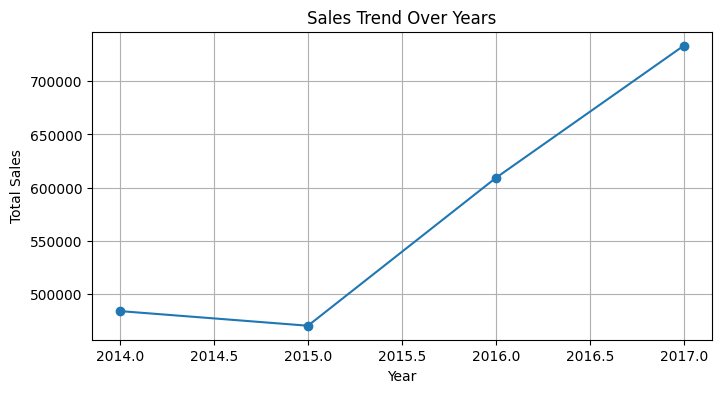

In [21]:
import matplotlib.pyplot as plt

# aggregate
sales_by_year = (
    df.groupby("Year", as_index=False)["Sales"]
      .sum()
      .sort_values("Year")
)

display(sales_by_year)

# plot
plt.figure(figsize=(8,4))
plt.plot(sales_by_year["Year"], sales_by_year["Sales"], marker="o")

plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

,Product_Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


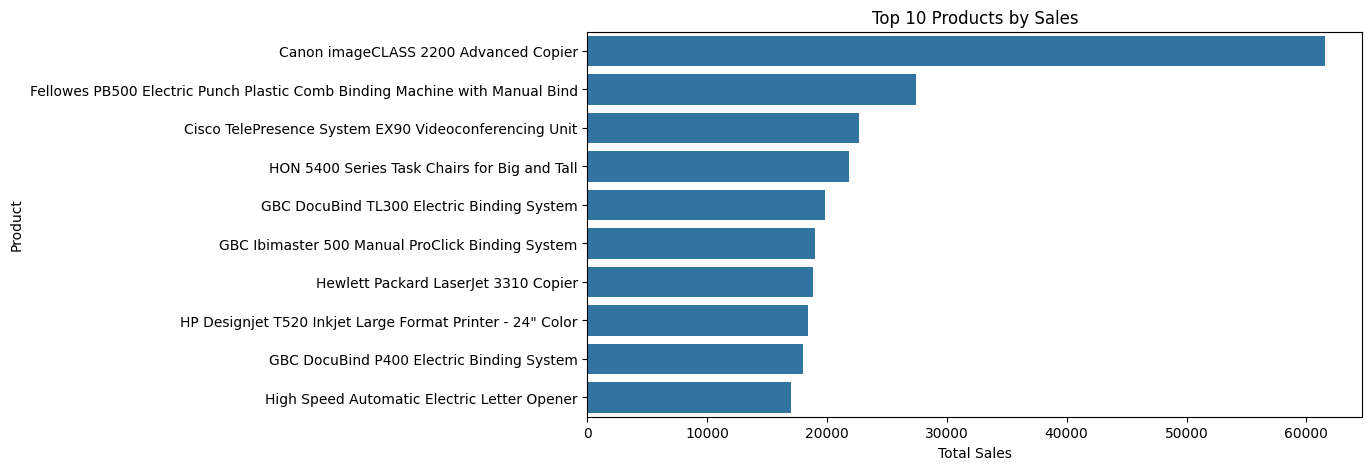

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = (
    df.groupby("Product_Name", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
      .head(10)
)

display(top10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="Sales", y="Product_Name")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

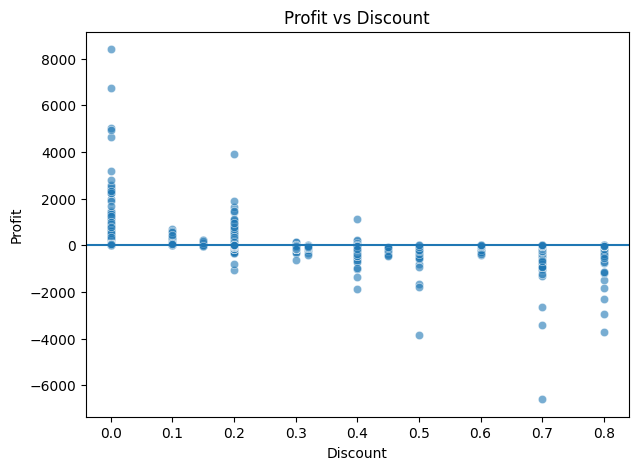

In [23]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.6
)

plt.axhline(0)
plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [24]:
import folium

state_sales = (
    df.groupby("State", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
)

display(state_sales.head())

,State,Sales
3,California,457687.6315
30,New York,310876.2710
41,Texas,170188.0458
45,Washington,138641.2700
36,Pennsylvania,116511.9140


In [26]:
import folium

m = folium.Map(location=[37, -96], zoom_start=4, tiles="CartoDB positron")

for _, row in state_sales.head(10).iterrows():
    folium.Marker(
        location=[37, -96],  # temporary center (next step we fix real positions)
        popup=f"{row['State']}: {row['Sales']:,.0f}"
    ).add_to(m)

m

In [27]:
import folium

us_states_geo = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/us-states.json"

m = folium.Map(location=[37, -96], zoom_start=4, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=us_states_geo,
    name="choropleth",
    data=state_sales,
    columns=["State", "Sales"],
    key_on="feature.properties.name",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Sales by State"
).add_to(m)

folium.LayerControl().add_to(m)

m

In [ ]:
# Insights from visualizations

# Sales trend (Matplotlib line chart)
# Sales slightly decreased in 2015.
# Strong growth occurred in 2016.
# 2017 shows the highest sales.
# Overall trend indicates business growth after 2015.

# Top products (Seaborn bar chart)
# One product (Canon imageCLASS 2200 Advanced Copier) dominates sales.
# Significant gap between the top product and others.
# High-value office equipment drives revenue.

# Profit vs Discount (Seaborn scatter)
# Clear negative relationship between discount and profit.
# Low discounts often produce positive profit.
# High discounts frequently lead to losses.
# Indicates aggressive discounting reduces profitability.

# Geographic distribution (Map)
# California generates the highest sales.
# New York and Texas are major contributors.
# Sales concentration exists in large economic states.

# Matplotlib vs Seaborn comparison

# Matplotlib
# Provides full control over plot customization.
# Better suited for building custom visualizations.
# Requires more code for styling.

# Seaborn
# Easier to create attractive statistical plots.
# Works directly with DataFrames and grouping.
# Faster for exploratory analysis.

# Conclusion
# Matplotlib is better for custom and interactive visualizations.
# Seaborn is better for quick statistical exploration.
# Using both together provides the most effective workflow.